In [1]:
import pandas as pd
import numpy as np
import statistics

In [2]:
df = pd.read_csv('metadados_completos_sol_sbc_portugues_2020_2025 - Métricas Linguísticas.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10066 entries, 0 to 10065
Data columns (total 87 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Id                               10066 non-null  int64  
 1   Title                            10066 non-null  object 
 2   Category                         10066 non-null  object 
 3   URL_Title                        10066 non-null  object 
 4   Authors                          10066 non-null  object 
 5   Event                            10066 non-null  object 
 6   Date                             10066 non-null  object 
 7   Box                              10066 non-null  object 
 8   Abstract                         10066 non-null  object 
 9   Keywords                         10066 non-null  object 
 10  Publisher                        10066 non-null  object 
 11  URL_Paper                        10066 non-null  object 
 12  Abstract_Language 

In [ ]:
df.head()

Medidas Estatísticas Descritivas 

In [20]:
list_metrics = df.columns.tolist()[15:]

df_metrics = pd.DataFrame(columns=['Métrica', 'n', 'Ano', 'Média', 'Mediana', 'Desvio Padrão'])

for metric in list_metrics:
    for year in range(2020, 2026):
        subset = df[df['Year'] == year]
        mean_value = subset[metric].mean()
        n = len(subset[metric])
        median_value = statistics.median(subset[metric].dropna())
        std_value = subset[metric].std()
        df_metrics = pd.concat([
            df_metrics,
            pd.DataFrame({
                'Métrica': [metric],
                'n': [n],
                'Ano': [year],
                'Média': [mean_value],
                'Mediana': [median_value],
                'Desvio Padrão': [std_value]  
            })
        ], ignore_index=True)

df_metrics.head(6)

C:\Users\05646078199\AppData\Local\Temp\ipykernel_3888\1888009323.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_metrics = pd.concat([


,Métrica,n,Ano,Média,Mediana,Desvio Padrão
0,adjective_ratio,962,2020,0.072000,0.07080,0.029075
1,adjective_ratio,1456,2021,0.074785,0.07258,0.030715
2,adjective_ratio,1262,2022,0.071944,0.07003,0.030017
3,adjective_ratio,1796,2023,0.073003,0.07143,0.029486
4,adjective_ratio,2447,2024,0.073316,0.07207,0.033841
5,adjective_ratio,2143,2025,0.085335,0.08434,0.033463


T-test Welch

In [21]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [24]:
df = df_metrics.copy()

baseline_years = [2020, 2021, 2022]


baseline_results = []


for metric in df['Métrica'].unique():
    df_metric = df[df['Métrica'] == metric]
    
    
    df_base = df_metric[df_metric['Ano'].isin(baseline_years)]
    
    
    n1 = df_base['n'].sum()
    
    
    s1_squared = np.sum((df_base['n'] - 1) * df_base['Desvio Padrão']**2) / (n1 - len(df_base))
    
    
    x1 = np.average(df_base['Média'], weights=df_base['n'])
    
    # Armazena resultado
    baseline_results.append({
        'Métrica': metric,
        'n_baseline': n1,
        'Média_baseline': x1,
        'Variância_baseline': s1_squared,
        'DP_baseline': np.sqrt(s1_squared)
    })

# Converte para DataFrame
df_baseline = pd.DataFrame(baseline_results)

df_baseline.head()

,Métrica,n_baseline,Média_baseline,Variância_baseline,DP_baseline
0,adjective_ratio,3680,0.073082,0.000903,0.030054
1,adverbs,3680,0.018017,0.000258,0.016048
2,content_words,3680,0.592842,0.001442,0.037979
3,flesch,3680,10.135474,221.515635,14.883401
4,function_words,3680,0.407158,0.001442,0.037979


In [44]:
df = df_metrics.copy()

# Definindo os anos pós-baseline
post_years = [2023, 2024, 2025]

# Inicializa lista para resultados do t-test
results = []

for metric in df['Métrica'].unique():
    # Busca baseline calculado
    base = df_baseline[df_baseline['Métrica'] == metric].iloc[0]
    x1 = base['Média_baseline']
    s1_squared = base['Variância_baseline']
    n1 = base['n_baseline']
    
    # Dados da métrica para anos pós-baseline
    df_metric_post = df[(df['Métrica'] == metric) & (df['Ano'].isin(post_years))]
    
    for idx, row in df_metric_post.iterrows():
        x2 = row['Média']
        s2_squared = row['Desvio Padrão']**2
        n2 = row['n']
        
        # Evita zero na variância
        s1_squared = max(s1_squared, 1e-10)
        s2_squared = max(s2_squared, 1e-10)
        n1_safe = max(n1, 2)
        n2_safe = max(n2, 2)
        
        # Erro padrão
        SE = np.sqrt(s1_squared / n1_safe + s2_squared / n2_safe)
        
        # t-statistic
        t_stat = (x1 - x2) / SE
        
        # Graus de liberdade aproximado de Welch
        numerator = (s1_squared/n1_safe + s2_squared/n2_safe)**2
        denominator = (s1_squared/n1_safe)**2 / (n1_safe - 1) + (s2_squared/n2_safe)**2 / (n2_safe - 1)
        df_welch = numerator / denominator if denominator != 0 else np.nan
        
        # p-value (t bilateral)
        if not np.isnan(df_welch):
            p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=df_welch))
        else:
            # aproximação normal se df inválido
            p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))
        
        # Diferença e interpretação
        diff = x2 - x1
        signif = "Altamente significativo" if p_val < 0.001 else ("Significativo" if p_val < 0.05 else "Não significativo")
        direction = "Aumento" if diff > 0 else ("Diminuição" if diff < 0 else "-")
        
        results.append({
            'Métrica': metric,
            'Ano': row['Ano'],
            'X1': x1,
            'n1': n1,
            's1_squared': s1_squared,
            'X2': x2,
            'n2': n2,
            's2_squared': s2_squared,
            'Diferença média': diff,
            't': t_stat,
            'p-value': p_val,
            'Significância': signif,
            'Direção': direction
        })

# Converte para DataFrame
df_results = pd.DataFrame(results)
df_results.head(10)
df_results.to_csv('analise_t_test_metricas_linguisticas.csv', index=False)


# Análise dos Resultados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df_results = pd.read_csv('analise_t_test_metricas_linguisticas - Grupos Linguísticos.csv')
df_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Grupo Linguístico  216 non-null    object 
 1   Métrica            216 non-null    object 
 2   Ano                216 non-null    int64  
 3   X1                 216 non-null    float64
 4   n1                 216 non-null    int64  
 5   s1_squared         216 non-null    float64
 6   X2                 216 non-null    float64
 7   n2                 216 non-null    int64  
 8   s2_squared         216 non-null    float64
 9   Diferença média    216 non-null    float64
 10  t                  216 non-null    float64
 11  p-value            216 non-null    float64
 12  Significância      216 non-null    object 
 13  Direção            216 non-null    object 
dtypes: float64(7), int64(3), object(4)
memory usage: 23.8+ KB


Quantidade de Métricas pela Categoria de Significância e Ano

In [ ]:

df_results.groupby('Ano')['Significância'].value_counts()

Ano   Significância          
2023  Não significativo          43
      Altamente significativo    16
      Significativo              13
2024  Altamente significativo    47
      Não significativo          15
      Significativo              10
2025  Altamente significativo    45
      Não significativo          20
      Significativo               7
Name: count, dtype: int64

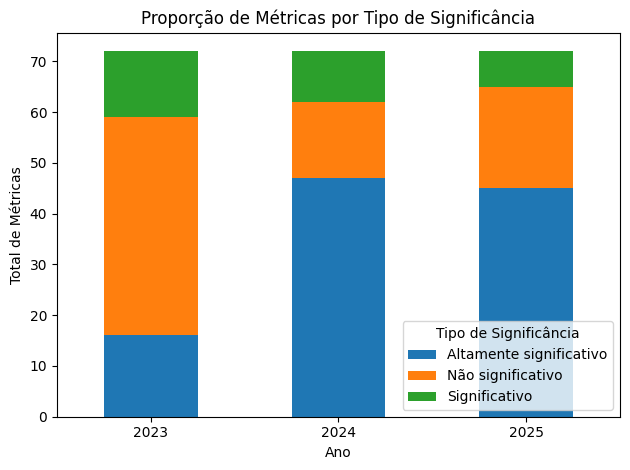

In [13]:
total = (
    df_results
    .groupby(['Ano', 'Significância'])
    .size()
    .reset_index(name='Total')
)

# Pivot
pivot_df = total.pivot(index='Ano', columns='Significância', values='Total')

# Plot stacked bar
pivot_df.plot(kind="bar", stacked=True)

plt.title("Proporção de Métricas por Tipo de Significância")
plt.xlabel("Ano")
plt.ylabel("Total de Métricas")
plt.legend(title="Tipo de Significância")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Quantidade de Métricas pela Direção da Significância e Ano

In [ ]:
df_results.groupby('Ano')['Direção'].value_counts()

Ano   Direção   
2023  Diminuição    37
      Aumento       32
      -              3
2024  Diminuição    41
      Aumento       28
      -              3
2025  Diminuição    40
      Aumento       29
      -              3
Name: count, dtype: int64

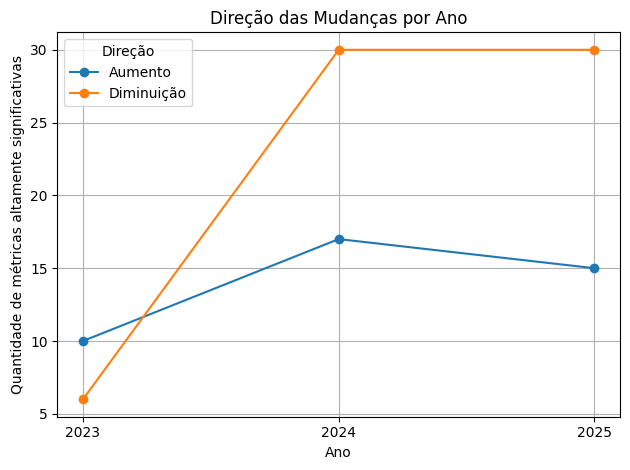

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# filtrar somente Altamente significativo
df_sig = df_results[df_results["Significância"] == "Altamente significativo"]

# agrupar apenas por Ano e Direção
grouped = (
    df_sig.groupby(["Ano", "Direção"])
    .size()
    .reset_index(name="Quantidade")
)

# pivot para formato Ano x Direção
pivot = grouped.pivot(index="Ano", columns="Direção", values="Quantidade").fillna(0)

# garantir ordem correta dos anos
pivot = pivot.reindex([2023, 2024, 2025])

# plot em linhas
pivot.plot(kind="line", marker="o")

plt.title("Direção das Mudanças por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de métricas altamente significativas")
plt.xticks([2023, 2024, 2025])
plt.legend(title="Direção")
plt.grid(True)

plt.tight_layout()
plt.show()


Quantificação Anual de Artigos com Z Score < 1 para Métricas Altamente Significativas presentes em Ambos os anos 2024 e 2025 

In [13]:
import pandas as pd
import numpy as np

In [23]:
df_results = pd.read_csv('analise_t_test_metricas_linguisticas - Grupos Linguísticos.csv')

In [15]:
metrics_key = (
    df_results
    .loc[
        (df_results['Ano'] == 2024) &
        (df_results['Significância'] == 'Altamente significativo'),
        'Métrica'
    ]
    .to_frame()
    .merge(
        df_results.loc[
            (df_results['Ano'] == 2025) &
            (df_results['Significância'] == 'Altamente significativo'),
            ['Métrica']
        ],
        on='Métrica'
    )['Métrica']
    .unique()
)

metrics_key = list(metrics_key)

metrics_key = [m for m in metrics_key if m in df.columns]

print(len(metrics_key))
print(metrics_key)

27
['adj_arg_ovl', 'arg_ovl', 'adj_stem_ovl', 'stem_ovl', 'adj_cw_ovl', 'lsa_adj_mean', 'dep_distance', 'logic_operators', 'and_ratio', 'cau_pos_conn_ratio', 'tmp_pos_conn_ratio', 'ttr', 'content_density', 'cw_freq_brwac', 'cw_freq_bra', 'brunet', 'adverbs', 'content_words', 'function_words', 'noun_ratio', 'personal_pronouns', 'ratio_function_to_content_words', 'hypernyms_verbs', 'adjectives_ambiguity', 'verbs_ambiguity', 'words_per_sentence', 'words']


In [16]:
# Converter variância em desvio-padrão
df_results['DP'] = np.sqrt(df_results['s2_squared'])
df_results.head()

,Grupo Linguístico,Métrica,Ano,X1,n1,s1_squared,X2,n2,s2_squared,Diferença média,t,p-value,Significância,Direção,DP
0,Coesão Referencial,adjacent_refs,2023,0.098673,3680,0.182816,0.090071,1796,0.125290,-0.008602,0.787103,4.312658e-01,Não significativo,Diminuição,0.353963
1,Coesão Referencial,adjacent_refs,2024,0.098673,3680,0.182816,0.074551,2447,0.098464,-0.024122,2.543883,1.098736e-02,Significativo,Diminuição,0.313790
2,Coesão Referencial,adjacent_refs,2025,0.098673,3680,0.182816,0.044126,2143,0.067706,-0.054547,6.050621,1.530000e-09,Altamente significativo,Diminuição,0.260203
3,Coesão Referencial,anaphoric_refs,2023,0.196494,3680,0.534377,0.187067,1796,0.441108,-0.009427,0.476838,6.335046e-01,Não significativo,Diminuição,0.664159
4,Coesão Referencial,anaphoric_refs,2024,0.196494,3680,0.534377,0.144301,2447,0.313905,-0.052192,3.155973,1.607549e-03,Significativo,Diminuição,0.560272


In [19]:
stats_lookup = {
    (row['Ano'], row['Métrica']): (row['X2'], row['DP'])
    for _, row in df_results.iterrows()
}
stats_lookup

{(2023, 'adjacent_refs'): (0.09007082405, 0.35396279493754707),
 (2024, 'adjacent_refs'): (0.07455063804, 0.31379029526102303),
 (2025, 'adjacent_refs'): (0.04412592627, 0.260202943334621),
 (2023, 'anaphoric_refs'): (0.1870669822, 0.6641594969583737),
 (2024, 'anaphoric_refs'): (0.1443013538, 0.5602724385511034),
 (2025, 'anaphoric_refs'): (0.08843852543, 0.4298173593516204),
 (2023, 'adj_arg_ovl'): (1.546566832, 1.3604110044394673),
 (2024, 'adj_arg_ovl'): (1.394606245, 1.2977589837870513),
 (2025, 'adj_arg_ovl'): (1.05798693, 1.0874343534209319),
 (2023, 'arg_ovl'): (1.460955657, 1.226740189689732),
 (2024, 'arg_ovl'): (1.35787007, 1.179531274701947),
 (2025, 'arg_ovl'): (1.056612058, 0.9483269414605915),
 (2023, 'adj_stem_ovl'): (2.178402288, 1.6817581820820733),
 (2024, 'adj_stem_ovl'): (1.930715652, 1.614519045412596),
 (2025, 'adj_stem_ovl'): (1.49622126, 1.357880442822563),
 (2023, 'stem_ovl'): (2.058061481, 1.5125421782548742),
 (2024, 'stem_ovl'): (1.879582982, 1.476875557384

In [ ]:
def compute_z_score(article_row, metric):
    key = (article_row['Year'], metric)

    if key not in stats_lookup:
        return np.nan

    mu, sd = stats_lookup[key]

    if sd == 0 or pd.isna(article_row[metric]):
        return np.nan

    return (article_row[metric] - mu) / sd

z_df = pd.DataFrame(index=df.index)

for metric in metrics_key:
    z_df[metric] = df.apply(
        compute_z_score,
        axis=1,
        metric=metric
    )

df['at_least_one_metric_z_lt_1'] = (z_df.abs() < 24).any(axis=1)

summary = (
    df
    .groupby('Year')['at_least_one_metric_z_lt_1']
    .agg(
        total_articles='count',
        articles_with_z_lt_1='sum'
    )
)

summary['percentage'] = (
    summary['articles_with_z_lt_1'] /
    summary['total_articles'] * 100
)


print(summary)


      total_articles  articles_with_z_lt_1  percentage
Year                                                  
2020             962                     0    0.000000
2021            1456                     0    0.000000
2022            1262                     0    0.000000
2023            1796                  1796  100.000000
2024            2447                  2445   99.918267
2025            2143                  2143  100.000000


In [ ]:
import pandas as pd
import numpy as np

def count_metrics_within_dp(article_row, year, k=1):
    count = 0

    for metric in metrics_key:
        key = (year, metric)

        if key not in stats_lookup:
            continue

        mu, sd = stats_lookup[key]

        if sd == 0 or pd.isna(sd):
            continue

        value = article_row.get(metric)

        if pd.isna(value):
            continue

        if (mu - k * sd) <= value <= (mu + k * sd):
            count += 1

    return count

# 1. Cálculo base: métricas dentro de ±1 DP por artigo

df['metrics_within_1dp'] = df.apply(
    lambda row: count_metrics_within_dp(row, row['Year']),
    axis=1
)


# 2. Loop pelos diferentes limiares de métricas
metric_thresholds = [10, 15, 20, 25, len(metrics_key)]

for MIN_METRICS in metric_thresholds:

    # Critério por artigo
    df['meets_criterion'] = (
        df['metrics_within_1dp'] >= MIN_METRICS
    )

    # Agregação por ano
    summary = (
        df
        .groupby('Year')
        .agg(
            total_articles=('meets_criterion', 'size'),
            articles_with_criterion=('meets_criterion', 'sum')
        )
        .reset_index()
    )

    summary['percentage'] = (
        summary['articles_with_criterion'] /
        summary['total_articles'] * 100
    )

    # Metadado explícito do critério
    summary['min_metrics'] = MIN_METRICS

    # 3. Exportação do CSV
    output_name = (
        f'resultado_dp_min_{MIN_METRICS}_metricas.csv'
    )

    summary.to_csv(
        output_name,
        index=False,
        encoding='utf-8'
    )

    print(f'Arquivo gerado: {output_name}')


Arquivo gerado: resultado_dp_min_10_metricas.csv
Arquivo gerado: resultado_dp_min_15_metricas.csv
Arquivo gerado: resultado_dp_min_20_metricas.csv
Arquivo gerado: resultado_dp_min_25_metricas.csv
Arquivo gerado: resultado_dp_min_27_metricas.csv


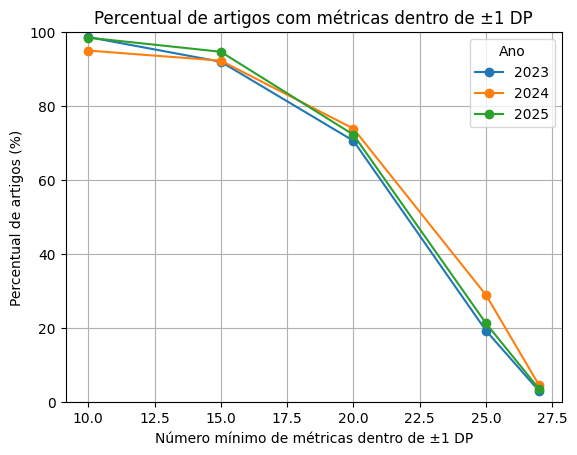

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Leitura e consolidação
files = [
    'resultado_dp_min_10_metricas.csv',
    'resultado_dp_min_15_metricas.csv',
    'resultado_dp_min_20_metricas.csv',
    'resultado_dp_min_25_metricas.csv',
    'resultado_dp_min_27_metricas.csv'
]

df_all = pd.concat(
    [pd.read_csv(f) for f in files],
    ignore_index=True
)

# Garantir ordenação correta no eixo X
df_all = df_all.sort_values('min_metrics')

# 2. Gráfico único (2023–2025)
plt.figure()

for year in [2023, 2024, 2025]:
    df_year = df_all[df_all['Year'] == year]

    plt.plot(
        df_year['min_metrics'],
        df_year['percentage'],
        marker='o',
        label=str(year)
    )

plt.xlabel('Número mínimo de métricas dentro de ±1 DP')
plt.ylabel('Percentual de artigos (%)')
plt.title('Percentual de artigos com métricas dentro de ±1 DP')
plt.ylim(0, 100)
plt.legend(title='Ano')
plt.grid(True)

plt.show()
